In [1]:
%load_ext autoreload
%autoreload 2

# allows to import modules from root directory
import sys
import os
sys.path.append(os.path.abspath('..'))

In [2]:
import GridWorld
import matplotlib.pyplot as plt
from renderer import GridWorldRenderer
import scipy.stats as stats
import numpy as np
from scipy.optimize import brentq

In [20]:
env = GridWorld.GridWorld(grid_size=8, glucose_target=50, glucose_max=100,
                 n_food=20, max_steps=200, metabolism_rate=1, intake_amount=10, 
                 drive_n=2, drive_m=1, seed=6)

In [84]:
# video rendering
renderer = GridWorldRenderer(env)
renderer.record_episode(out_path="episode.mp4", fps=1)

KeyboardInterrupt: 

In [21]:
all_glucose = [env._get_obs()["glucose_level"]]
all_reward = [null_reward := 0]  # Initialize with a placeholder for the first step
all_drive = [env._get_obs()["drive"]]
for t in range(100):
    step = env.step()
    all_glucose.append(step[0]["glucose_level"])
    all_drive.append(step[0]["drive"])
    all_reward.append(step[1])

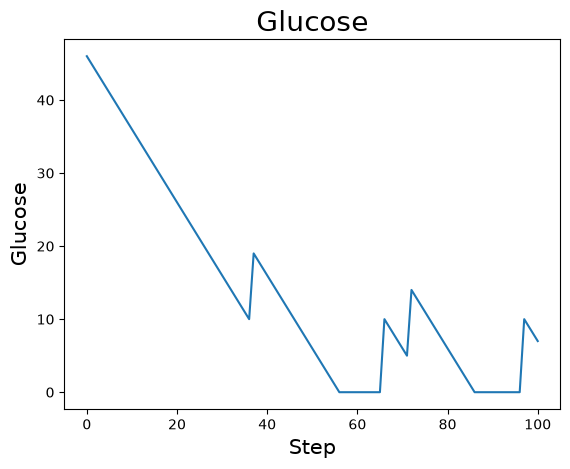

In [7]:
plt.plot(all_glucose)
plt.xlabel("Step", fontsize=15)
plt.ylabel("Glucose", fontsize=15)
plt.title("Glucose", fontsize=20)
#plt.savefig("../plots/glucose-m3-i10.png", dpi=300, bbox_inches='tight')
plt.show()

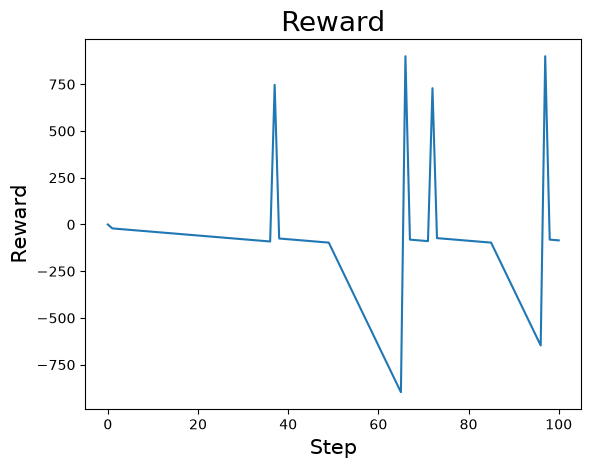

In [71]:
plt.plot(all_reward)
plt.xlabel("Step", fontsize=15)
plt.ylabel("Reward", fontsize=15)
plt.title("Reward", fontsize=20)
#plt.savefig("../plots/reward_drive_n1.png", dpi=300, bbox_inches='tight')
plt.show()

In [66]:
print(all_reward)
print(all_glucose)

[0, -9.0, -11.0, -13.0, -15.0, -17.0, -19.0, -21.0, -23.0, -25.0, -27.0, -29.0, -31.0, -33.0, 225.0, -17.0, -19.0, -21.0, -23.0, -25.0, -27.0, -29.0, -31.0, -33.0, -35.0, -37.0, -39.0, -41.0, -43.0, -45.0, -47.0, -49.0, -51.0, -53.0, -55.0, -57.0, 441.0, -41.0, -43.0, -45.0, -47.0, -49.0, -51.0, -53.0, -55.0, -57.0, -59.0, -61.0, -63.0, -65.0, -67.0, -69.0, -71.0, -73.0, -75.0, -77.0, -79.0, -81.0, -83.0, -85.0, -87.0, -89.0, -91.0, -93.0, -95.0, 783.0, -79.0, -81.0, -83.0, -85.0, -87.0, 711.0, -71.0, -73.0, -75.0, -77.0, -79.0, -81.0, -83.0, -85.0, -87.0, -89.0, -91.0, -93.0, -95.0, -97.0, -147.0, -197.0, -247.0, -297.0, -347.0, -397.0, -447.0, -497.0, -547.0, -597.0, 900.0, -81.0, -83.0, -85.0, -87.0]
[46, 45, 44, 43, 42, 41, 40, 39, 38, 37, 36, 35, 34, 33, 42, 41, 40, 39, 38, 37, 36, 35, 34, 33, 32, 31, 30, 29, 28, 27, 26, 25, 24, 23, 22, 21, 30, 29, 28, 27, 26, 25, 24, 23, 22, 21, 20, 19, 18, 17, 16, 15, 14, 13, 12, 11, 10, 9, 8, 7, 6, 5, 4, 3, 2, 11, 10, 9, 8, 7, 6, 15, 14, 13, 12

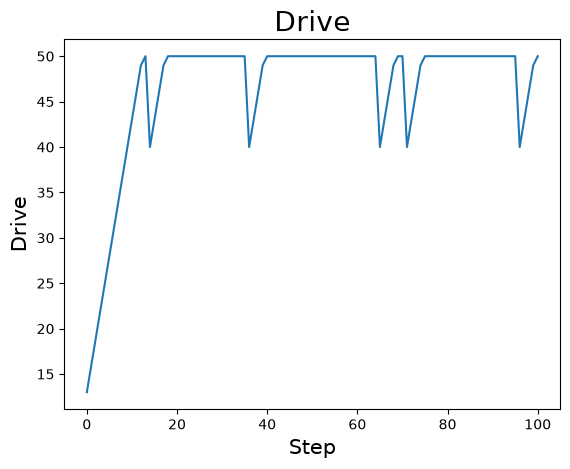

In [49]:
plt.plot(all_drive)
plt.xlabel("Step", fontsize=15)
plt.ylabel("Drive", fontsize=15)
plt.title("Drive", fontsize=20)
plt.savefig("../plots/drive_drive_n1.png", dpi=300, bbox_inches='tight')
plt.show()

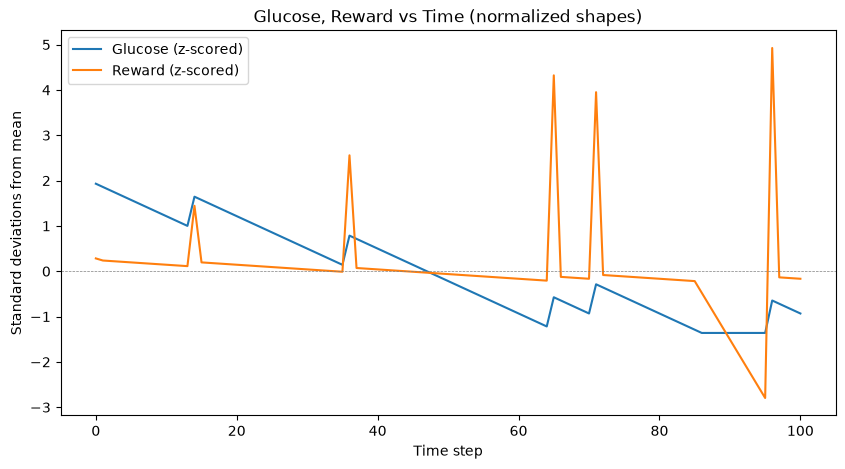

In [22]:
glucose_z = stats.zscore(all_glucose)
reward_z = stats.zscore(all_reward)

plt.figure(figsize=(10, 5))
plt.plot(glucose_z, label='Glucose (z-scored)')
plt.plot(reward_z, label='Reward (z-scored)')
plt.axhline(0, color='gray', linewidth=0.5, linestyle='--')
plt.xlabel('Time step')
plt.ylabel('Standard deviations from mean')
plt.title('Glucose, Reward vs Time (normalized shapes)')
plt.legend()
plt.savefig("../plots/glucose-reward-m1.png", dpi=300, bbox_inches='tight')
plt.show()

### Reward and Drive Curves

In [8]:
def reward(action=None, glucose_level=None, glucose_target=None, metabolism=None, intake=None):
    if (action == 'EAT'):
        return (2*glucose_level-2*glucose_target-metabolism+intake)*(metabolism-intake)
    else:
        return (2*glucose_level-2*glucose_target-metabolism)*(metabolism)

In [19]:
glucose_range = np.linspace(0, 100, 1000)
glucose_target = 50
metabolism = 5
intake = 10
action = 'EAT'

rewards = reward(action, glucose_range, glucose_target, metabolism, intake)

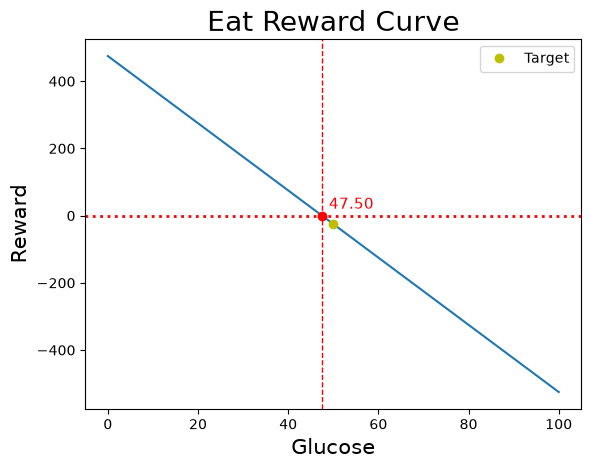

In [23]:
# 2. Exact root-finding using the actual function (not the sampled array)
#    Pick bounds where you know the function changes sign
x_zero = brentq(lambda glucose_level: reward(action, glucose_level, glucose_target, metabolism, intake), 0, 100)

# 3. Plot
plt.plot(glucose_range, rewards)
plt.axhline(y=0, color='r', linestyle=':', linewidth=2)

plt.axvline(x=x_zero, color='r', linestyle='--', linewidth=1)
plt.plot(x_zero, 0, 'ro')
plt.annotate(f'{x_zero:.2f}', (x_zero, 0), textcoords="offset points",
             xytext=(5, 5), fontsize=11, color='red')

plt.plot(glucose_target, reward(action, glucose_target, glucose_target, metabolism, intake), 'yo', label = 'Target')

plt.xlabel("Glucose", fontsize=15)
plt.ylabel("Reward", fontsize=15)
plt.title("Eat Reward Curve", fontsize=20)
plt.legend()
plt.savefig("../plots/eat-reward.png", dpi=300, bbox_inches='tight')
plt.show()

In [9]:
glucose_range = np.linspace(0, 100, 1000)
glucose_target = 50
action = 'EAT'

#metabolisms = [1, 5, 10, 15]
metabolism = 5

#intake = 10
intakes = [1, 5, 10, 15]

rewards = {}
for i in intakes:
    rewards[i] = reward(action=action, glucose_level=glucose_range, glucose_target=glucose_target, metabolism=metabolism, intake=i)

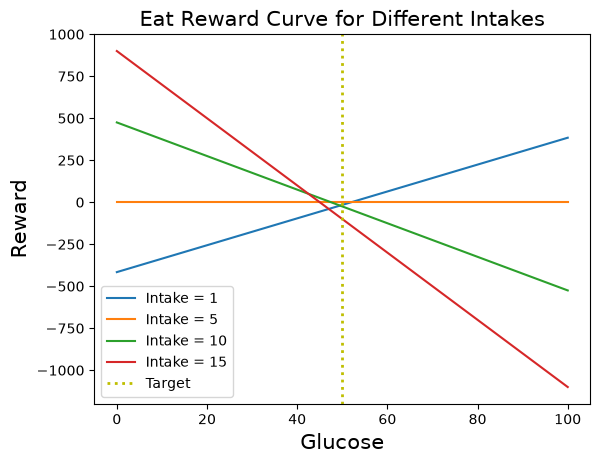

In [10]:
for i in intakes:
    plt.plot(glucose_range, rewards[i], label=f'Intake = {i}')
plt.xlabel("Glucose", fontsize=15)
plt.ylabel("Reward", fontsize=15)
plt.title("Eat Reward Curve for Different Intakes", fontsize=15)
#plt.axhline(y=0, color='r', linestyle=':', linewidth=2)
plt.axvline(x=glucose_target, color='y', linestyle=':', linewidth=2, label='Target')
plt.legend()
plt.savefig("../plots/eat-reward-diff-i.png", dpi=300, bbox_inches='tight')
plt.show()

In [18]:
def drive(glucose_level=None, glucose_target=None, n=None, m=None):
    return ((abs(glucose_level - glucose_target)) ** n) ** (1/m)

In [12]:
glucose_range = np.linspace(0, 100, 1000)
glucose_target = 50
n=4
m=3

drives = drive(glucose_range, glucose_target, n, m)

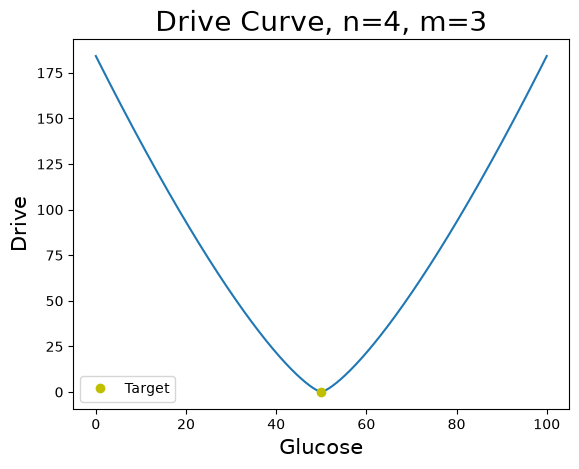

In [13]:
plt.plot(glucose_range, drives)
plt.xlabel("Glucose", fontsize=15)
plt.ylabel("Drive", fontsize=15)
plt.title(f"Drive Curve, n={n}, m={m}", fontsize=20)
plt.plot(glucose_target, drive(glucose_target, glucose_target, n, m), 'yo', label = 'Target')
plt.legend()
plt.savefig(f"../plots/drive-curve-n{n}-m{m}.png", dpi=300, bbox_inches='tight')

In [19]:
def reward(action=None, glucose_level=None, glucose_target=None, metabolism=None, intake=None, n=None, m=None):
    cur_drive = drive(glucose_level, glucose_target, n, m)
    if (action == 'EAT'):
        next_glucose = glucose_level + intake - metabolism
    else:
        next_glucose = glucose_level - metabolism
    next_drive = drive(next_glucose, glucose_target, n, m)
    return cur_drive - next_drive

In [26]:
glucose_range = np.linspace(0, 100, 1000)
glucose_target = 50
action = 'EAT'

metabolism = 5
#metabolisms = [1, 5, 10, 15]

#intake = 10
intakes = [1, 5, 10, 15]

n=2
m=3

In [202]:
rewards = reward(action=action, glucose_level=glucose_range, glucose_target=glucose_target, metabolism=metabolism, intake=intake, n=n, m=m)

In [27]:
rewards = {}
for i in intakes:
    rewards[i] = reward(action=action, glucose_level=glucose_range, glucose_target=glucose_target, metabolism=metabolism, intake=i, n=n, m=m)

In [237]:
print(rewards[5])

[-4.13750000e+04 -4.12174926e+04 -4.10602859e+04 -4.09033797e+04
 -4.07467742e+04 -4.05904692e+04 -4.04344649e+04 -4.02787611e+04
 -4.01233580e+04 -3.99682554e+04 -3.98134535e+04 -3.96589521e+04
 -3.95047514e+04 -3.93508512e+04 -3.91972517e+04 -3.90439527e+04
 -3.88909544e+04 -3.87382567e+04 -3.85858595e+04 -3.84337630e+04
 -3.82819670e+04 -3.81304717e+04 -3.79792769e+04 -3.78283828e+04
 -3.76777893e+04 -3.75274963e+04 -3.73775040e+04 -3.72278123e+04
 -3.70784211e+04 -3.69293306e+04 -3.67805407e+04 -3.66320513e+04
 -3.64838626e+04 -3.63359745e+04 -3.61883870e+04 -3.60411000e+04
 -3.58941137e+04 -3.57474280e+04 -3.56010429e+04 -3.54549583e+04
 -3.53091744e+04 -3.51636911e+04 -3.50185084e+04 -3.48736263e+04
 -3.47290447e+04 -3.45847638e+04 -3.44407835e+04 -3.42971038e+04
 -3.41537247e+04 -3.40106462e+04 -3.38678682e+04 -3.37253909e+04
 -3.35832142e+04 -3.34413381e+04 -3.32997626e+04 -3.31584877e+04
 -3.30175134e+04 -3.28768397e+04 -3.27364666e+04 -3.25963941e+04
 -3.24566222e+04 -3.23171

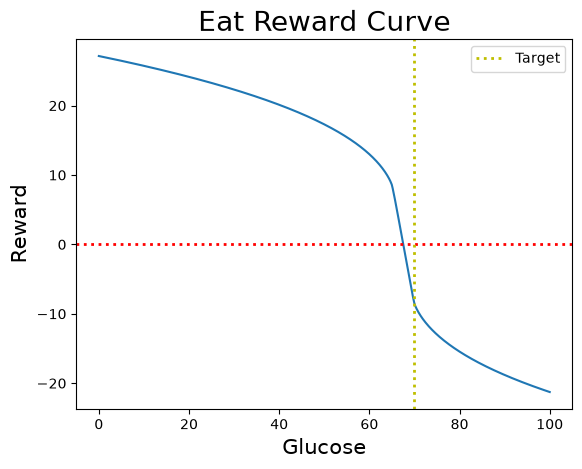

In [ ]:
# 2. Exact root-finding using the actual function (not the sampled array)
#    Pick bounds where you know the function changes sign
#x_zero = brentq(lambda glucose_level: reward(action, glucose_level, glucose_target, metabolism, intake), 0, 100)

# 3. Plot
plt.plot(glucose_range, rewards)
plt.axhline(y=0, color='r', linestyle=':', linewidth=2)

#plt.axvline(x=x_zero, color='r', linestyle='--', linewidth=1)
#plt.plot(x_zero, 0, 'ro')
#plt.annotate(f'{x_zero:.2f}', (x_zero, 0), textcoords="offset points",
#             xytext=(5, 5), fontsize=11, color='red')

plt.axvline(x=glucose_target, color='y', linestyle=':', linewidth=2, label='Target')

plt.xlabel("Glucose", fontsize=15)
plt.ylabel("Reward", fontsize=15)
plt.title("Eat Reward Curve", fontsize=20)
plt.legend()
plt.savefig("../plots/n4-m3-g70.png", dpi=300, bbox_inches='tight')
plt.show()

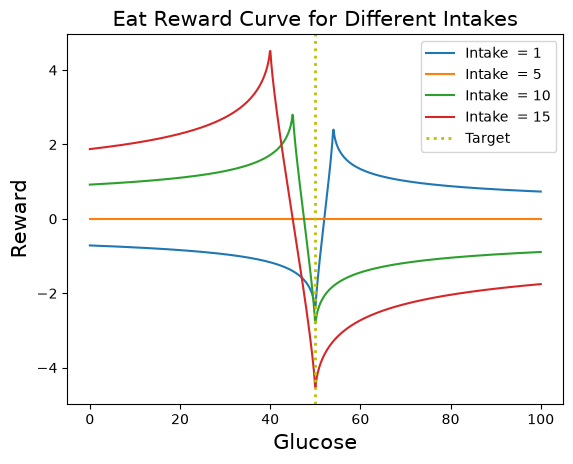

In [28]:
for i in intakes:
    plt.plot(glucose_range, rewards[i], label=f'Intake  = {i}')
plt.xlabel("Glucose", fontsize=15)
plt.ylabel("Reward", fontsize=15)
plt.title("Eat Reward Curve for Different Intakes", fontsize=15)
#plt.axhline(y=0, color='r', linestyle=':', linewidth=2)
plt.axvline(x=glucose_target, color='y', linestyle=':', linewidth=2, label='Target')
plt.legend()
plt.savefig("../plots/n2-m3-diff-intakes.png", dpi=300, bbox_inches='tight')
plt.show()